In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Telco Customer Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df = df.drop("customerID", axis=1)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7032 non-null   category
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   int64   
 3   Dependents        7032 non-null   int64   
 4   tenure            7032 non-null   int64   
 5   InternetService   7032 non-null   object  
 6   Contract          7032 non-null   object  
 7   PaperlessBilling  7032 non-null   int64   
 8   PaymentMethod     7032 non-null   object  
 9   MonthlyCharges    7032 non-null   float64 
 10  TotalCharges      7032 non-null   float64 
 11  Churn             7032 non-null   int64   
 12  ServiceCount      7032 non-null   int64   
 13  PhoneBundle       7032 non-null   int64   
dtypes: category(1), float64(2), int64(8), object(3)
memory usage: 776.1+ KB


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

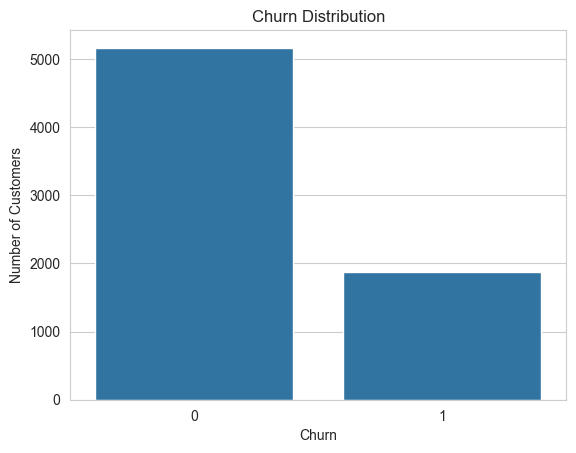

<Figure size 640x480 with 0 Axes>

In [62]:
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()
plt.savefig('grafik_adi.png', dpi=300, bbox_inches='tight')

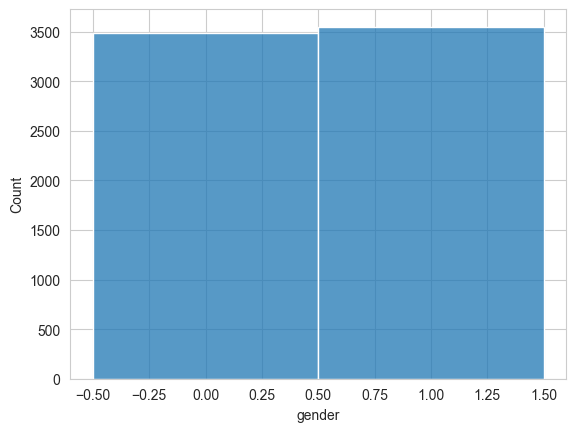

In [63]:
sns.histplot(df["gender"])
plt.show()


In [11]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [13]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [14]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']].head()

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


In [15]:
df = df[df['TotalCharges'].notna()]

In [16]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


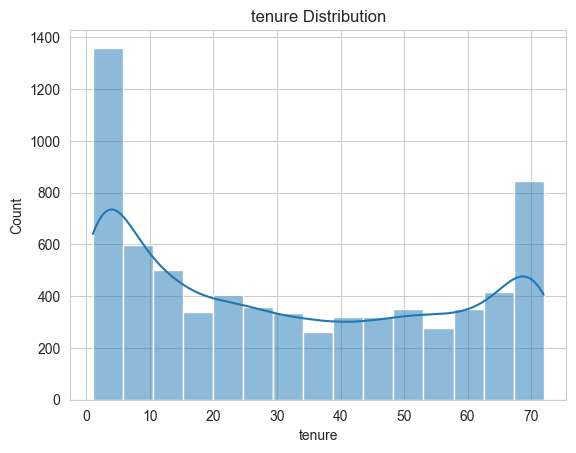

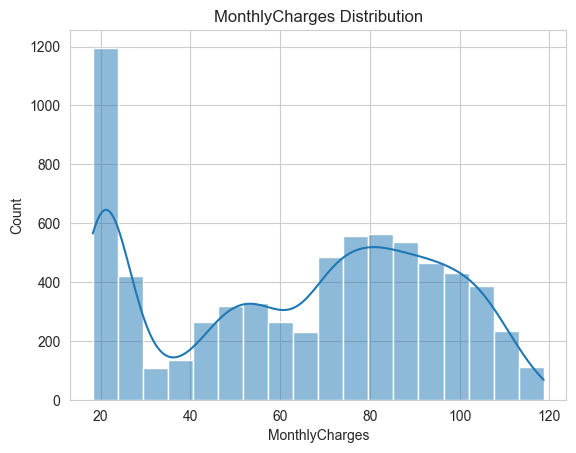

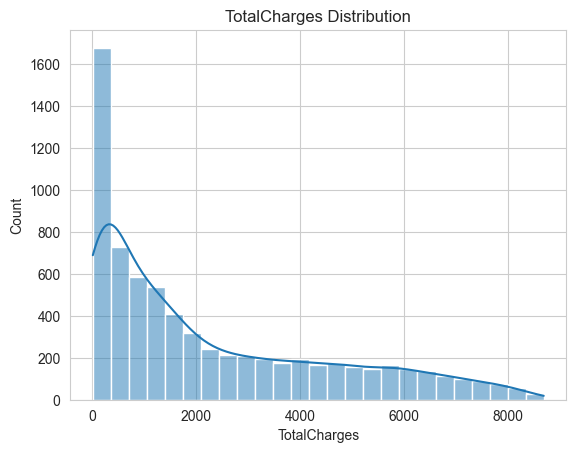

In [58]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()


In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

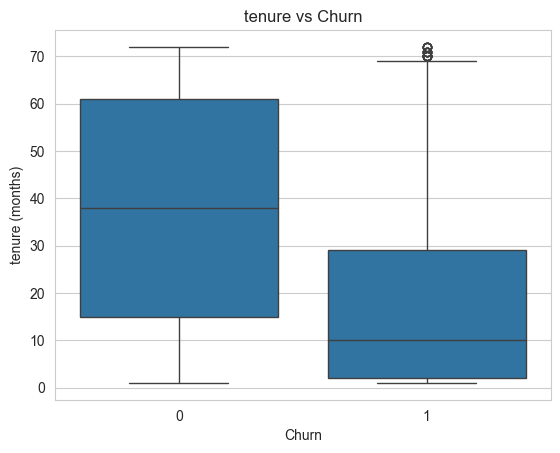

In [59]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("tenure (months)")
plt.show()


In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [21]:
yes_no_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [22]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

for col in service_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })


/var/folders/d9/nv9w39_13ng1hsdz60kqn8vw0000gn/T/ipykernel_75258/4166174685.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [23]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [24]:
df['ServiceCount'] = df[service_cols].sum(axis=1)

In [26]:
df = df.drop(columns=[
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
])


In [27]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ServiceCount
0,0,0,1,0,1,0,0,DSL,Month-to-month,1,Electronic check,29.85,29.85,0,1
1,1,0,0,0,34,1,0,DSL,One year,0,Mailed check,56.95,1889.50,0,2
2,1,0,0,0,2,1,0,DSL,Month-to-month,1,Mailed check,53.85,108.15,1,2
3,1,0,0,0,45,0,0,DSL,One year,0,Bank transfer (automatic),42.30,1840.75,0,3
4,0,0,0,0,2,1,0,Fiber optic,Month-to-month,1,Electronic check,70.70,151.65,1,0


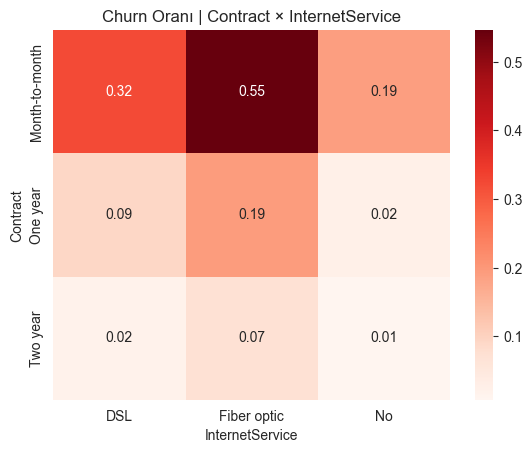

In [28]:
pivot_ci = (
    df.pivot_table(
        values='Churn',
        index='Contract',
        columns='InternetService',
        aggfunc='mean'
    )
)

sns.heatmap(pivot_ci, annot=True, fmt=".2f", cmap="Reds")
plt.title("Churn Oranı | Contract × InternetService")
plt.show()


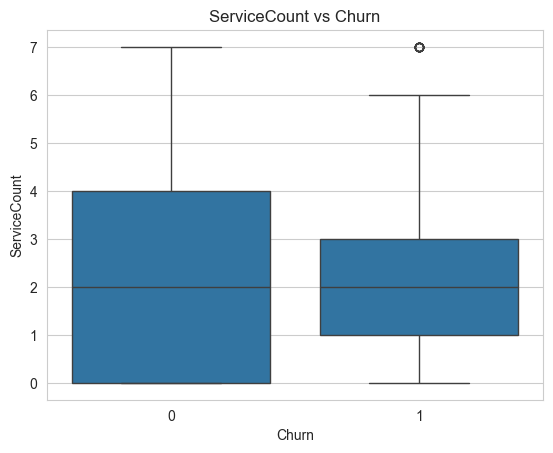

In [29]:
sns.boxplot(data=df, x='Churn', y='ServiceCount')
plt.title("ServiceCount vs Churn")
plt.show()


In [30]:
df.groupby('ServiceCount')['Churn'].mean()

ServiceCount
0    0.208058
1    0.345156
2    0.377220
3    0.312883
4    0.257787
5    0.218359
6    0.116667
7    0.052885
Name: Churn, dtype: float64

In [31]:
df['PhoneBundle'] = df['PhoneService'] + df['MultipleLines']
df = df.drop(columns=['PhoneService','MultipleLines'])


In [32]:
df['gender'] = df['gender'].astype('category')


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7032 non-null   category
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   int64   
 3   Dependents        7032 non-null   int64   
 4   tenure            7032 non-null   int64   
 5   InternetService   7032 non-null   object  
 6   Contract          7032 non-null   object  
 7   PaperlessBilling  7032 non-null   int64   
 8   PaymentMethod     7032 non-null   object  
 9   MonthlyCharges    7032 non-null   float64 
 10  TotalCharges      7032 non-null   float64 
 11  Churn             7032 non-null   int64   
 12  ServiceCount      7032 non-null   int64   
 13  PhoneBundle       7032 non-null   int64   
dtypes: category(1), float64(2), int64(8), object(3)
memory usage: 776.1+ KB


In [34]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

In [35]:
cat_cols = ['InternetService', 'Contract', 'PaymentMethod', 'gender']
num_cols = [c for c in num_cols if c != 'Churn']


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [39]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [40]:
log_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


In [41]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [43]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [44]:
# TRAIN
y_train_pred = log_model.predict(X_train)
y_train_prob = log_model.predict_proba(X_train)[:, 1]

# TEST
y_test_pred = log_model.predict(X_test)
y_test_prob = log_model.predict_proba(X_test)[:, 1]


In [45]:
print("===== TRAIN RESULTS =====")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("ROC AUC:", roc_auc_score(y_train, y_train_prob))
print(classification_report(y_train, y_train_pred))

print("\n===== TEST RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print(classification_report(y_test, y_test_pred))


===== TRAIN RESULTS =====
Accuracy: 0.7443555555555555
ROC AUC: 0.8392280968846924
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      4130
           1       0.51      0.81      0.63      1495

    accuracy                           0.74      5625
   macro avg       0.71      0.77      0.72      5625
weighted avg       0.81      0.74      0.76      5625


===== TEST RESULTS =====
Accuracy: 0.7164179104477612
ROC AUC: 0.8322496648047586
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.81      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.75      0.69      1407
weighted avg       0.79      0.72      0.73      1407



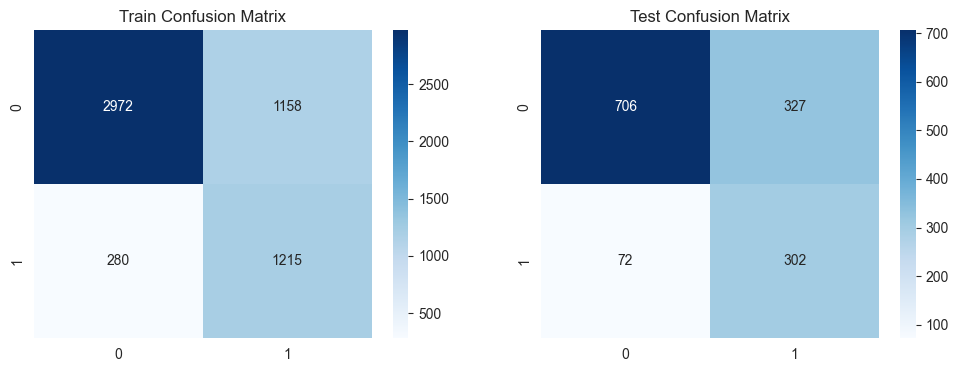

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(confusion_matrix(y_train, y_train_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Train Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, y_test_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Test Confusion Matrix")

plt.show()

In [47]:
feature_names = (
    log_model.named_steps['preprocess']
    .get_feature_names_out()
)

# katsayılar
coefs = log_model.named_steps['model'].coef_[0]

# tablo
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

feat_imp.head(15)

,feature,coef,abs_coef
6,cat__Contract_Two year,-1.695217,1.695217
0,num__tenure,-1.219814,1.219814
3,cat__InternetService_Fiber optic,1.020723,1.020723
4,cat__InternetService_No,-0.951317,0.951317
5,cat__Contract_One year,-0.905889,0.905889
2,num__TotalCharges,0.627378,0.627378
8,cat__PaymentMethod_Electronic check,0.535293,0.535293
1,num__MonthlyCharges,-0.136742,0.136742
7,cat__PaymentMethod_Credit card (automatic),0.052788,0.052788
9,cat__PaymentMethod_Mailed check,-0.017839,0.017839


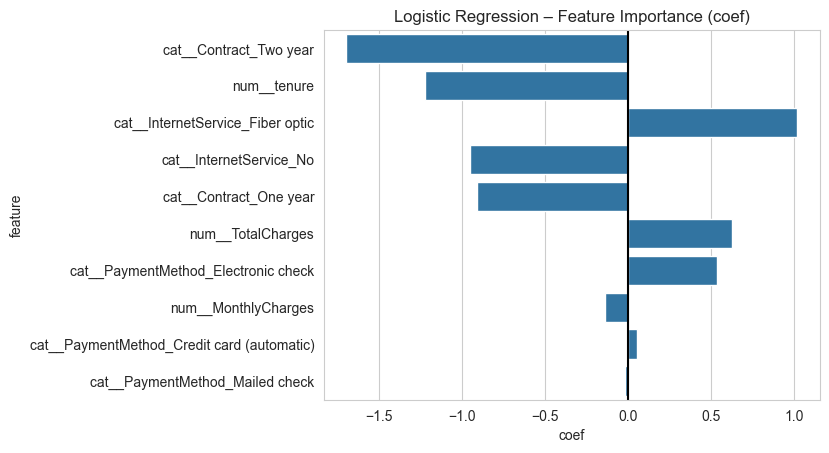

In [48]:
top_n = 10
top_features = feat_imp.head(top_n)

sns.barplot(
    data=top_features,
    x='coef',
    y='feature',
    orient='h'
)
plt.axvline(0, color='black')
plt.title("Logistic Regression – Feature Importance (coef)")
plt.show()


In [49]:
from catboost import CatBoostClassifier, Pool

In [50]:
for c in cat_cols:
    X_train[c] = X_train[c].astype(str)
    X_test[c]  = X_test[c].astype(str)

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_cols)

In [52]:
cb = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced",
    early_stopping_rounds=100
)

In [53]:
cb.fit(train_pool, eval_set=test_pool, use_best_model=True)

0:	test: 0.7919240	best: 0.7919240 (0)	total: 62.8ms	remaining: 2m 5s
200:	test: 0.8382689	best: 0.8382689 (200)	total: 986ms	remaining: 8.82s
400:	test: 0.8395942	best: 0.8401067 (341)	total: 2.08s	remaining: 8.3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.840106693
bestIteration = 341

Shrink model to first 342 iterations.


In [54]:
train_prob = cb.predict_proba(train_pool)[:, 1]
test_prob  = cb.predict_proba(test_pool)[:, 1]

train_pred = (train_prob >= 0.5).astype(int)
test_pred  = (test_prob  >= 0.5).astype(int)

print("===== TRAIN RESULTS =====")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("ROC AUC:", roc_auc_score(y_train, train_prob))
print(classification_report(y_train, train_pred))

print("\n===== TEST RESULTS =====")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC AUC:", roc_auc_score(y_test, test_prob))
print(classification_report(y_test, test_pred))

===== TRAIN RESULTS =====
Accuracy: 0.7712
ROC AUC: 0.8736884854276159
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      4130
           1       0.55      0.83      0.66      1495

    accuracy                           0.77      5625
   macro avg       0.74      0.79      0.74      5625
weighted avg       0.82      0.77      0.78      5625


===== TEST RESULTS =====
Accuracy: 0.7370291400142146
ROC AUC: 0.8401066930336334
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



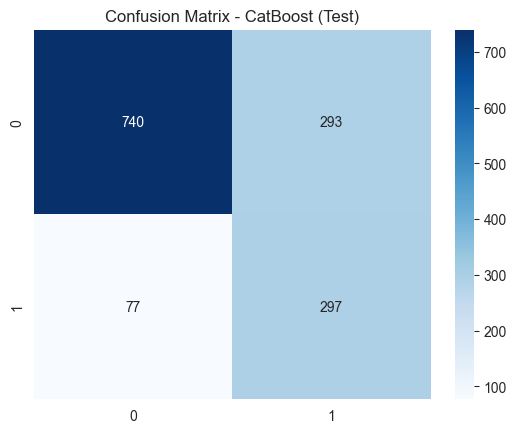

In [55]:
sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - CatBoost (Test)")
plt.show()

,feature,importance
0,Contract,27.217016
1,tenure,14.386038
2,InternetService,13.841672
3,TotalCharges,10.970052
4,MonthlyCharges,8.273111
5,PaymentMethod,6.516089
6,PhoneBundle,5.355178
7,ServiceCount,3.345728
8,PaperlessBilling,3.031433
9,Dependents,2.494125


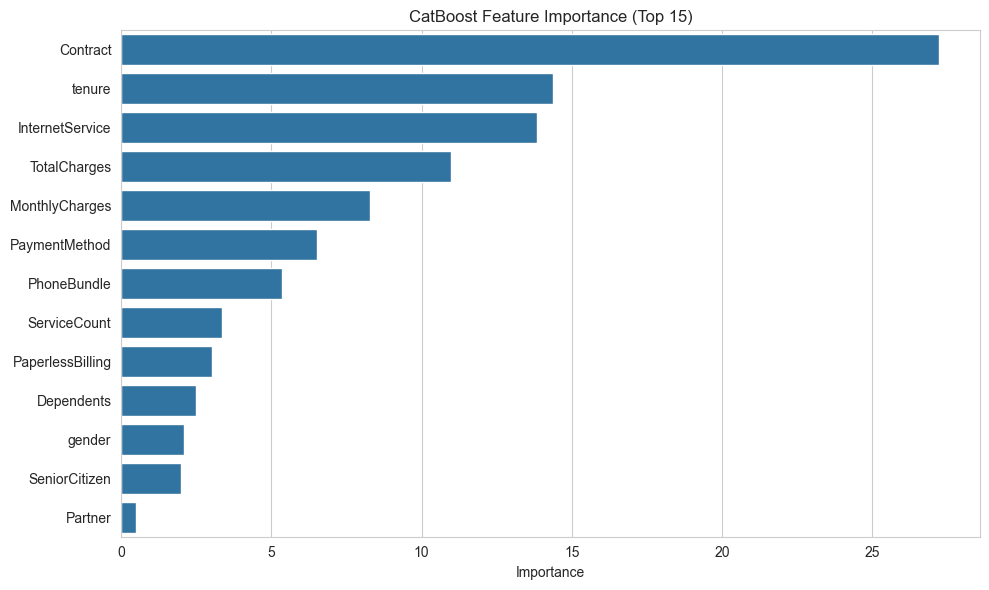

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Feature importance al (varsayılan: PredictionValuesChange)
# alternatif: type="LossFunctionChange" (daha yavaş ama daha sağlam) / type="ShapValues"
imp = cb.get_feature_importance(train_pool, type="PredictionValuesChange")

feat_imp = (pd.DataFrame({
    "feature": X_train.columns,
    "importance": imp
})
.sort_values("importance", ascending=False)
.reset_index(drop=True))

# 2) Top N tablo
top_n = 15
display(feat_imp.head(top_n))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(top_n), x="importance", y="feature", orient="h")
plt.title(f"CatBoost Feature Importance (Top {top_n})")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()

plt.savefig('important.png', dpi=300, bbox_inches='tight')
plt.show()